<a href="https://colab.research.google.com/github/MrAndrew30/MIREA_TIMO2/blob/main/TIMO1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа 1.1

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

In [31]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [32]:
print("Количество объектов в обучающей выборке:", x_train.shape[0])
print("Количество объектов в тестовой выборке:", x_test.shape[0])
print("Размерность одного объекта:", x_train[0].shape)
print("Тип меток:", y_train.dtype)
print("Диапазон значений пикселей: ", "[", x_train.min(), "; ", x_train.max(), "]", sep="")
print("Уникальные классы:", np.unique(y_train))

Количество объектов в обучающей выборке: 60000
Количество объектов в тестовой выборке: 10000
Размерность одного объекта: (28, 28)
Тип меток: uint8
Диапазон значений пикселей: [0; 255]
Уникальные классы: [0 1 2 3 4 5 6 7 8 9]


In [33]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Диапазон после нормализации (train): ", "[",
      x_train.min(), "; ",
      x_train.max(), "]", sep="")
print("Диапазон после нормализации (test): ", "[",
      x_test.min(), "; ",
      x_test.max(), "]", sep="")

Диапазон после нормализации (train): [0.0; 1.0]
Диапазон после нормализации (test): [0.0; 1.0]


In [34]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Размерность обучающей выборки после преобразования:", x_train.shape)
print("Размерность тестовой выборки после преобразования:", x_test.shape)

Размерность обучающей выборки после преобразования: (60000, 784)
Размерность тестовой выборки после преобразования: (10000, 784)


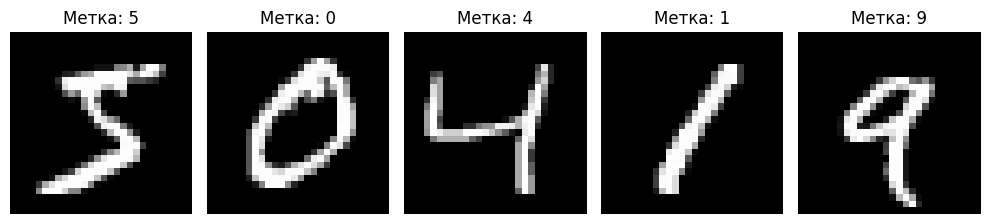

In [35]:
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Метка: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Практическая работа 1.2

In [36]:
model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8658 - loss: 0.4551 - val_accuracy: 0.9710 - val_loss: 0.0992
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9669 - loss: 0.1106 - val_accuracy: 0.9763 - val_loss: 0.0841
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9763 - loss: 0.0743 - val_accuracy: 0.9743 - val_loss: 0.0865
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9830 - loss: 0.0532 - val_accuracy: 0.9777 - val_loss: 0.0889
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9867 - loss: 0.0419 - val_accuracy: 0.9772 - val_loss: 0.0882
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9889 - loss: 0.0337 - val_accuracy: 0.9772 - val_loss: 0.0884
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9909 - loss: 0.0284 - val_accuracy: 0.9795 - val_loss: 0.0857
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9925 - loss: 0.0232 

In [39]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy на тестовой выборке: {test_accuracy:.4f}")
print(f"Лосс на тестовой выборке: {test_loss:.4f}")

Accuracy на тестовой выборке: 0.9756
Лосс на тестовой выборке: 0.0998


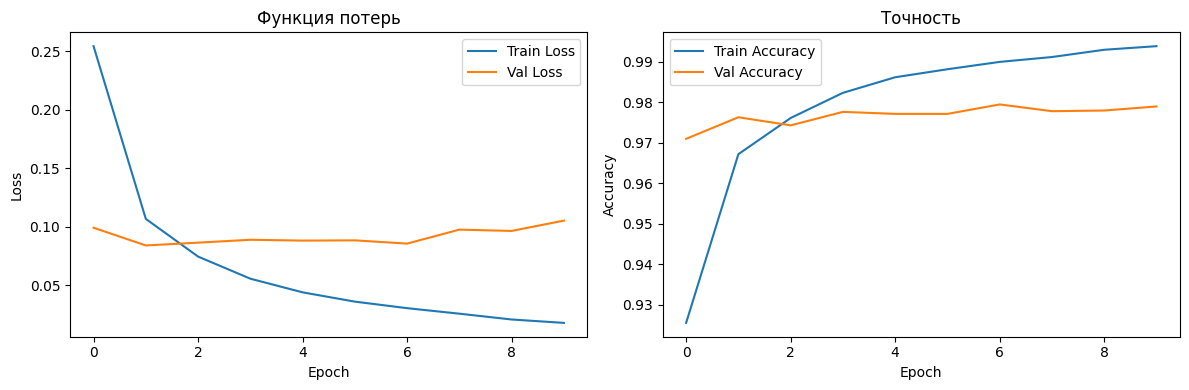

In [40]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Функция потерь')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Точность')

plt.tight_layout()
plt.show()

In [41]:
print("Анализ базовой модели")
print(f"Разница train/val loss (последняя эпоха): {history.history['loss'][-1]:.4f} / {history.history['val_loss'][-1]:.4f}")
print(f"Разница train/val accuracy (последняя эпоха): {history.history['accuracy'][-1]:.4f} / {history.history['val_accuracy'][-1]:.4f}")

Анализ базовой модели
Разница train/val loss (последняя эпоха): 0.0180 / 0.1053
Разница train/val accuracy (последняя эпоха): 0.9939 / 0.9790


In [42]:
model_reg = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [43]:
history_reg = model_reg.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7877 - loss: 0.6817 - val_accuracy: 0.9615 - val_loss: 0.1276
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9362 - loss: 0.2157 - val_accuracy: 0.9728 - val_loss: 0.0969
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9496 - loss: 0.1685 - val_accuracy: 0.9750 - val_loss: 0.0860
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9564 - loss: 0.1441 - val_accuracy: 0.9778 - val_loss: 0.0798
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9641 - loss: 0.1194 - val_accuracy: 0.9790 - val_loss: 0.0734
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9679 - loss: 0.1097 - val_accuracy: 0.9780 - val_loss: 0.0730
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9666 - loss: 0.1083 - val_accuracy: 0.9798 - val_loss: 0.0714
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9677 - loss: 0.1000 

In [44]:
test_loss_reg, test_accuracy_reg = model_reg.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy на тестовой выборке (с регуляризацией): {test_accuracy_reg:.4f}")
print(f"Лосс на тестовой выборке (с регуляризацией): {test_loss_reg:.4f}")

Accuracy на тестовой выборке (с регуляризацией): 0.9771
Лосс на тестовой выборке (с регуляризацией): 0.0781


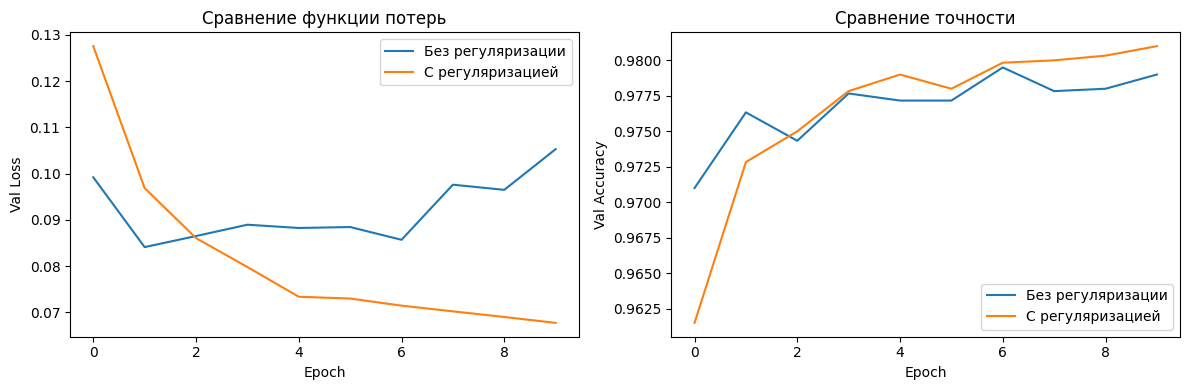

In [45]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='Без регуляризации')
plt.plot(history_reg.history['val_loss'], label='С регуляризацией')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend()
plt.title('Сравнение функции потерь')

plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='Без регуляризации')
plt.plot(history_reg.history['val_accuracy'], label='С регуляризацией')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.title('Сравнение точности')

plt.tight_layout()
plt.show()

In [46]:
predictions = model_reg.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

errors = np.where(predicted_labels != y_test)[0]

print(f"Всего ошибок: {len(errors)} из {len(y_test)}")
print(f"Процент ошибок: {len(errors)/len(y_test)*100:.2f}%")

Всего ошибок: 229 из 10000
Процент ошибок: 2.29%


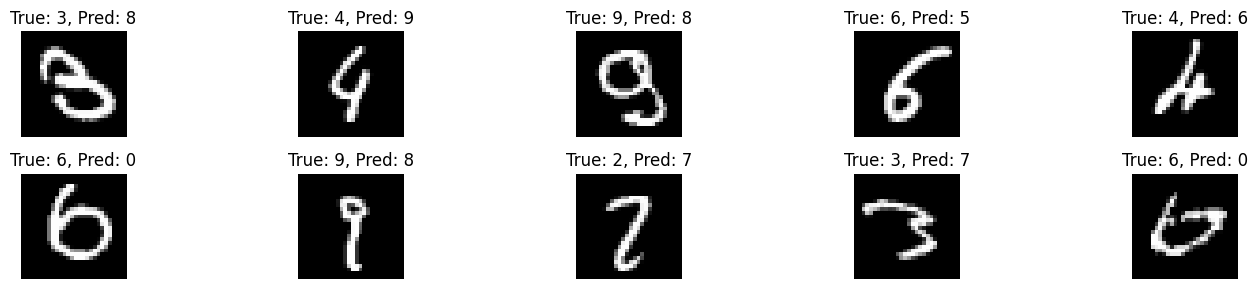

In [47]:
plt.figure(figsize=(15, 3))
for i in range(min(10, len(errors))):
    idx = errors[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {predicted_labels[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()